In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import plot_tree

warnings.filterwarnings('ignore')

In [88]:
df=pd.read_csv(r"C:\Users\Samaira Singh\Downloads\bootcamp\ml\Metro_Interstate_Traffic_Volume.csv")
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00,4918


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [90]:
#encoding multiple categorical columns weather_main,weather_desc
# Identify object columns
obj_cols = df.select_dtypes(include=['object']).columns

# Initialize and apply OrdinalEncoder to all columns simultaneously
encoder = OrdinalEncoder()
df[obj_cols] = encoder.fit_transform(df[obj_cols])

In [91]:
feat=["holiday","temp","rain_1h","snow_1h","clouds_all","weather_main","weather_description"]
X=df.drop(columns=["traffic_volume"]).values
Y=df["traffic_volume"].values
feauture_names=df.drop(columns=["traffic_volume"]).columns.tolist()

In [92]:
#splitting dataset for training and testing .20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

RANDOM FOREST

In [93]:
#n_estimators=100: Number of decision trees in the forest.
#random_state=42: Ensures reproducible results.
#oob_score=True: Uses out-of-bag samples to estimate model performance.

from sklearn.model_selection import cross_val_score
regressor = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=2,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

regressor.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [94]:
df.dtypes


holiday                float64
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main           float64
weather_description    float64
date_time              float64
traffic_volume           int64
dtype: object

In [98]:
#oob_score_: Retrive out-of-bag (OOB) score which estimates 
#the model's generalization performance

print("Out-of-Bag Score:", regressor.oob_score_)

# predictions are made on the test set.
y_pred = regressor.predict(X_test)

#Evaluates the model's performance using the Mean Squared Error (MSE) and R-squared (R2) metrics.
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

#cross-validation
cv_scores = cross_val_score(regressor, X, Y, cv=5, scoring='r2',n_jobs=-1)
print(f"\n 5 fold cv scores:{cv_scores}")

Out-of-Bag Score: 0.4231273824389675
Mean Squared Error: 2226300.5069796983
R-squared: 0.43688051812400297

 5 fold cv scores:[-0.11693834 -0.07018143 -0.09113465 -0.04169521 -0.04929152]


OOB SCORE: Measures how well the model generalizes on unseen samples, a low value indicates weaker generalization.

MSE:Average squared difference between actual and predicted values, lower values indicate better predictions.

R-SQUARED:Indicates how much variance in the target variable is explained by the model, values close to 1 show a strong fit.

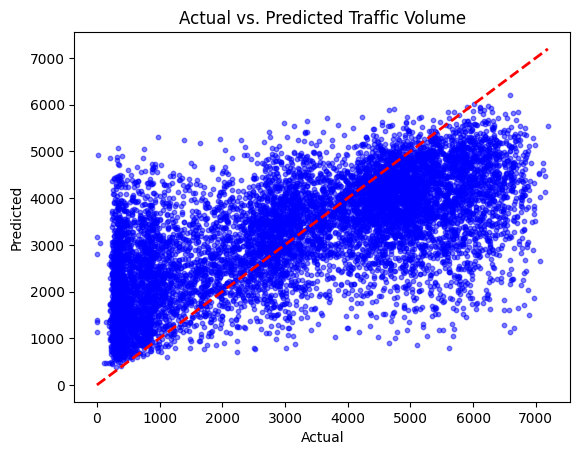

In [97]:
# Plot actual vs predicted
plt.scatter(y_test, y_pred, color='blue', alpha=0.5,s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs. Predicted Traffic Volume")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

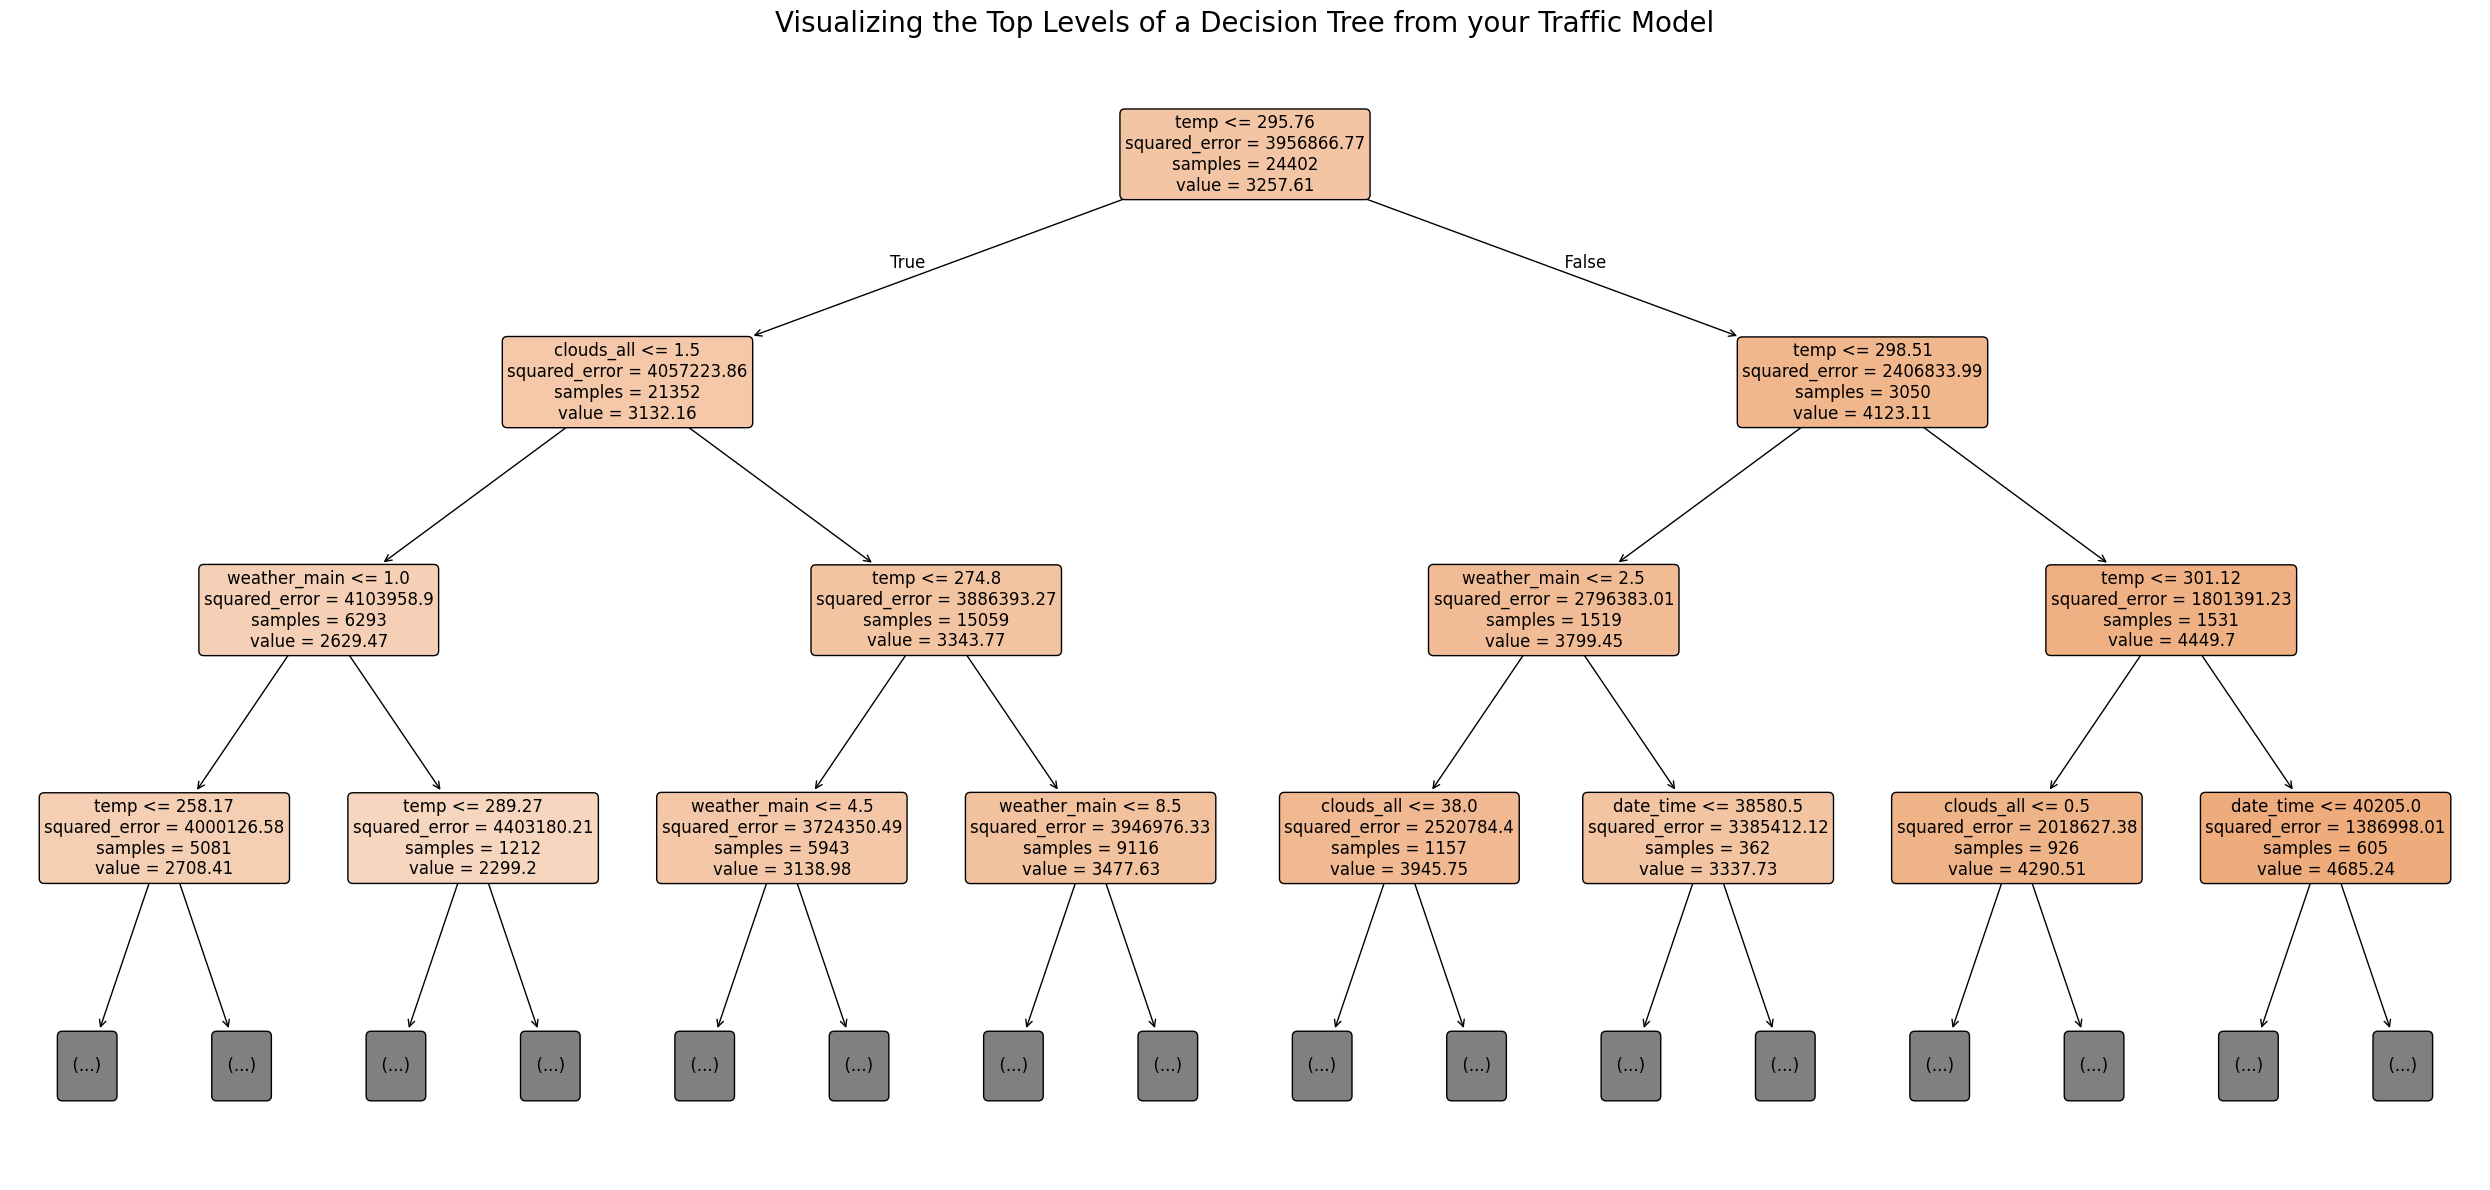

In [85]:
# Select the first tree in your forest
tree_to_plot = regressor.estimators_[0]

# Set up the figure size for a large, clear graph
fig, ax = plt.subplots(figsize=(25, 12))

# Use plot_tree with important pruning parameters
plot_tree(tree_to_plot, 
          max_depth=3,                   
          feature_names=df.drop(columns=["traffic_volume"]).columns.tolist(), 
          filled=True,                    
          rounded=True,                    
          fontsize=12,                     
          precision=2,                    
          ax=ax)                         

# Add a title and adjust layout
plt.title("Visualizing the Top Levels of a Decision Tree from your Traffic Model", fontsize=20)
plt.tight_layout()

# Show the plot
plt.show()

The code visualizes one of the decision trees from the trained Random Forest model.

ADABOOST
The code visualizes one of the decision trees from the trained Random Forest model.

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [29]:
#Initializing model parameters like number of estimators, weights and models.

#The constructor (__init__) initializes the number of weak models (n_estimators)
#to a list to store the alphas (self.alphas) and a list to store the weak classifiers 
#(self.models)
class AdaBoost:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.alphas = []
        self.models = []

In [30]:
def fit(self, X, y):
        n_samples, n_features = X.shape  
        w = np.ones(n_samples) / n_samples #initializes all sample weights equally.

        for _ in range(self.n_estimators):
            model = DecisionTreeClassifier(max_depth=1)  
            model.fit(X, y, sample_weight=w)  
            predictions = model.predict(X)  

            err = np.sum(w * (predictions != y)) / np.sum(w)  #computes the weighted error of the classifier.

            alpha = 0.5 * np.log((1 - err) / (err + 1e-10))  #calculates the classifier's weight (alpha).

            self.models.append(model) 
            self.alphas.append(alpha)  

            w *= np.exp(-alpha * y * predictions)  
            w /= np.sum(w)   #Misclassified samples weights are increased and normalised

In [31]:
#n the predict() method we combine the predictions of all weak classifiers
#using their respective alpha values to make the final prediction
def predict(self, X):
        strong_preds = np.zeros(X.shape[0])  

        for model, alpha in zip(self.models, self.alphas):
            predictions = model.predict(X)  
            strong_preds += alpha * predictions  

        return np.sign(strong_preds).astype(int)#takes the sign of the sum to classify samples as 1 (positive class) or -1 (negative class).

In [33]:
#We are generating a synthetic dataset with 1000 samples and 20 features.
#Then, we split the data into training and testing sets.
#We initialize and train an AdaBoost classifier with 50 estimators.
#After training, we predict on the test set and evaluate the model.
if __name__ == "__main__":

    X, Y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

    adaboost = AdaBoostClassifier(n_estimators=50)
    adaboost.fit(X_train, y_train)

    predictions = adaboost.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    try:
        roc_auc = roc_auc_score(y_test, predictions)
    except ValueError:
        roc_auc = 'Undefined (requires probability scores)'

    print(f"Accuracy: {accuracy * 100}%")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print(f"ROC-AUC: {roc_auc}")

Accuracy: 84.66666666666667%
Precision: 0.8609271523178808
Recall: 0.8387096774193549
F1 Score: 0.8496732026143791
ROC-AUC: 0.8469410456062292


XGBOOST

In [44]:
import xgboost as xgb  

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42,stratify=Y)


In [46]:
#using stratify helped maintain same percentage of data in training and testing
print(sum(y_train)/len(y_train))
print(sum(y_test)/len(y_test))

0.5
0.5


In [61]:
#early stopping to stop building trees when they no longer improve the situation
clf_xgb=xgb.XGBClassifier(objective="binary:logistic",seed=42,missing=float('nan'),eval_metric="aucpr",early_stopping_rounds=10)
clf_xgb.fit(X_train,y_train,verbose=True,eval_set=[(X_test,y_test)])

[0]	validation_0-aucpr:0.94993
[1]	validation_0-aucpr:0.94756
[2]	validation_0-aucpr:0.95449
[3]	validation_0-aucpr:0.96127
[4]	validation_0-aucpr:0.96378
[5]	validation_0-aucpr:0.96334
[6]	validation_0-aucpr:0.96505
[7]	validation_0-aucpr:0.96429
[8]	validation_0-aucpr:0.96599
[9]	validation_0-aucpr:0.96465
[10]	validation_0-aucpr:0.96600
[11]	validation_0-aucpr:0.96580
[12]	validation_0-aucpr:0.96566
[13]	validation_0-aucpr:0.96570
[14]	validation_0-aucpr:0.96582
[15]	validation_0-aucpr:0.96647
[16]	validation_0-aucpr:0.96535
[17]	validation_0-aucpr:0.96533
[18]	validation_0-aucpr:0.96540
[19]	validation_0-aucpr:0.96550
[20]	validation_0-aucpr:0.96547
[21]	validation_0-aucpr:0.96517
[22]	validation_0-aucpr:0.96630
[23]	validation_0-aucpr:0.96579
[24]	validation_0-aucpr:0.96613
[25]	validation_0-aucpr:0.96567


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,10
,enable_categorical,True
,eval_metric,'aucpr'


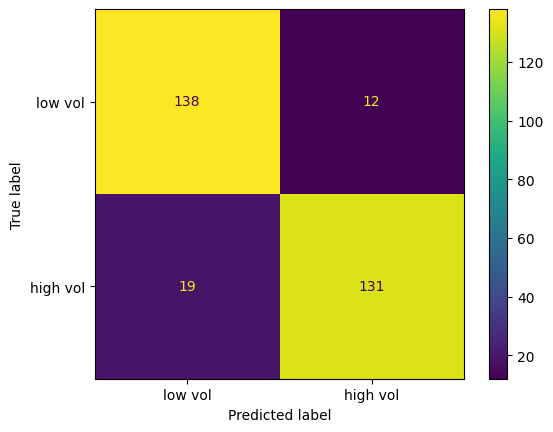

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf_xgb,X_test,y_test,values_format="d",display_labels=["low vol", "high vol"])

in the confusuion matrix 138(92%) records were correctly classified to have lower traffic volume .131(87.3%) records were correctly classified to have higher traffic volume 

In [67]:
138/(138+12)

0.92

In [68]:
131/(19+131)

0.8733333333333333